# Clasificación Binaria de Audio con PyTorch: Voz Femenina vs Masculina
## Dataset: Audios Female (0) y Male (1) (.wav)

In [1]:
import os
import math
import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import soundfile as sf
import librosa
import IPython.display as ipd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo detectado:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('Dispositivo en uso   :', device)

Dispositivo detectado: NVIDIA GeForce RTX 4050 Laptop GPU
Dispositivo en uso   : cuda


In [2]:
female_dir = 'Female'
male_dir   = 'Male'

BATCH_SIZE = 32
EPOCHS     = 100
PATIENCE   = 8
LR         = 0.001

In [3]:

def extraer_caracteristicas(ruta_audio, n_mfcc=20):
    data, sr = sf.read(ruta_audio)
    if data.ndim > 1:
        data = np.mean(data, axis=1)  
    y = data[::2]                     
    sr_sub = sr // 2
    mfccs = librosa.feature.mfcc(y=y, sr=sr_sub, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std  = np.std(mfccs, axis=1)
    return np.hstack([mfcc_mean, mfcc_std])

female_files = sorted(glob.glob(os.path.join(female_dir, '*.wav')))
male_files   = sorted(glob.glob(os.path.join(male_dir, '*.wav')))

caracteristicas_lista = []
etiquetas_lista = []

print(f'Extrayendo características de {len(female_files)} audios de Female...')
for ruta in female_files:
    caracteristicas_lista.append(extraer_caracteristicas(ruta))
    etiquetas_lista.append(0.0)  

print(f'Extrayendo características de {len(male_files)} audios de Male...')
for ruta in male_files:
    caracteristicas_lista.append(extraer_caracteristicas(ruta))
    etiquetas_lista.append(1.0)  

X = np.array(caracteristicas_lista, dtype=np.float32)
y = np.array(etiquetas_lista, dtype=np.float32)

clases    = ['female', 'male']
input_dim = X.shape[1]

print('\nTotal de audios procesados:', len(X))
print('Dimensión de entrada (features):', input_dim)
print('Clases binarias                : 0 = female, 1 = male')

Extrayendo características de 300 audios de Female...
Extrayendo características de 300 audios de Male...

Total de audios procesados: 600
Dimensión de entrada (features): 40
Clases binarias                : 0 = female, 1 = male


In [4]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y
)

mean = X_train_raw.mean(axis=0)
std  = X_train_raw.std(axis=0)
std[std == 0] = 1.0  

print('Media (mean) - primeros 5 valores    :', mean[:5].round(4))
print('Desv. Est. (std) - primeros 5 valores:', std[:5].round(4))


X_train = (X_train_raw - mean) / std
X_test  = (X_test_raw  - mean) / std

train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_data  = TensorDataset(torch.tensor(X_test,  dtype=torch.float32), torch.tensor(y_test,  dtype=torch.float32))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print()
print('Audios de entrenamiento:', len(train_data))
print('Audios de prueba (test):', len(test_data))
print('Dimensión de entrada   :', input_dim)

x_b, y_b = next(iter(train_loader))
print()
print('Verificación del lote (batch):')
print('  Forma de las características :', x_b.shape)
print('  Forma de las etiquetas       :', y_b.shape)
print('  Tipo de tensor               :', x_b.dtype)
print('  Rango normalizado            : min =', round(x_b.min().item(), 3), '| max =', round(x_b.max().item(), 3))

Media (mean) - primeros 5 valores    : [-88.6528 109.3435   8.6614  18.4514  10.9882]
Desv. Est. (std) - primeros 5 valores: [68.258  25.4699 13.7144 10.1239  9.23  ]

Audios de entrenamiento: 480
Audios de prueba (test): 120
Dimensión de entrada   : 40

Verificación del lote (batch):
  Forma de las características : torch.Size([32, 40])
  Forma de las etiquetas       : torch.Size([32])
  Tipo de tensor               : torch.float32
  Rango normalizado            : min = -2.955 | max = 3.672


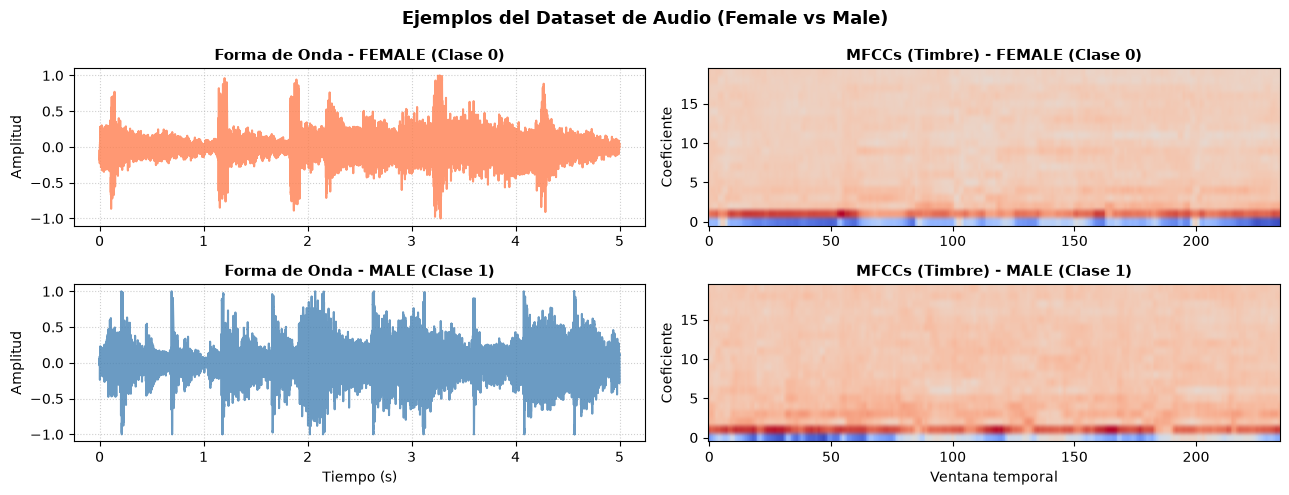

Reproducir muestra Female (0):


Reproducir muestra Male (1):


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 5), dpi=100)

ejemplos_rutas = [female_files[0], male_files[0]]

for i, (cls, ruta) in enumerate(zip(clases, ejemplos_rutas)):
    data, sr = sf.read(ruta)
    if data.ndim > 1:
        data = np.mean(data, axis=1)
    
    tiempo = np.linspace(0, len(data)/sr, num=len(data))
    color = 'coral' if i == 0 else 'steelblue'

    axes[i, 0].plot(tiempo, data, color=color, alpha=0.8)
    axes[i, 0].set_title(f'Forma de Onda - {cls.upper()} (Clase {i})', fontsize=11, fontweight='bold')
    axes[i, 0].set_ylabel('Amplitud')
    axes[i, 0].grid(True, linestyle=':', alpha=0.6)
    if i == 1:
        axes[i, 0].set_xlabel('Tiempo (s)')
        
    
    mfcc_ej = librosa.feature.mfcc(y=data[::2], sr=sr//2, n_mfcc=20)
    axes[i, 1].imshow(mfcc_ej, aspect='auto', origin='lower', cmap='coolwarm')
    axes[i, 1].set_title(f'MFCCs (Timbre) - {cls.upper()} (Clase {i})', fontsize=11, fontweight='bold')
    axes[i, 1].set_ylabel('Coeficiente')
    if i == 1:
        axes[i, 1].set_xlabel('Ventana temporal')

plt.suptitle('Ejemplos del Dataset de Audio (Female vs Male)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Reproducir muestra Female (0):')
display(ipd.Audio(female_files[0]))
print('Reproducir muestra Male (1):')
display(ipd.Audio(male_files[0]))

In [6]:

model = nn.Sequential(
    nn.Flatten(),

    nn.Linear(input_dim, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 1)
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal de parámetros entrenables: {total_params:,}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=40, out_features=512, bias=True)
  (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=256, out_features=1, bias=True)
)

Total de parámetros entrenables: 154,113


In [7]:

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4) # l2
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

mejor_loss  = float('inf')
sin_mejora  = 0
mejor_epoca = 1
CHECKPOINT  = 'mejor_modelo.pt'

print('Iniciando entrenamiento binario...\n')

for epoca in range(1, EPOCHS + 1):
    model.train()
    loss_train, preds_train, real_train = 0.0, [], []

    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        
        salida = model(X_b).squeeze(1)  # Salida 1D de tamaño [batch_size]
        loss   = criterion(salida, y_b)
        loss.backward()
        optimizer.step()

        loss_train  += loss.item() * len(y_b)
        probs        = torch.sigmoid(salida)
        preds        = (probs >= 0.5).int()
        preds_train += preds.cpu().tolist()
        real_train  += y_b.int().cpu().tolist()

    model.eval()
    loss_test, preds_test, real_test = 0.0, [], []

    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            salida    = model(X_b).squeeze(1)
            loss_test += criterion(salida, y_b).item() * len(y_b)
            
            probs       = torch.sigmoid(salida)
            preds       = (probs >= 0.5).int()
            preds_test += preds.cpu().tolist()
            real_test  += y_b.int().cpu().tolist()

    scheduler.step()

    avg_train = loss_train / len(train_data)
    avg_test  = loss_test  / len(test_data)
    acc_train = accuracy_score(real_train, preds_train)
    acc_test  = accuracy_score(real_test,  preds_test)

    train_losses.append(avg_train);  test_losses.append(avg_test)
    train_accs.append(acc_train);    test_accs.append(acc_test)

    if avg_test < mejor_loss:
        mejor_loss  = avg_test
        mejor_epoca = epoca
        sin_mejora  = 0
        torch.save(model.state_dict(), CHECKPOINT)
        estado_guardado = ' [Guardado OK]'
    else:
        sin_mejora += 1
        estado_guardado = f' [Sin mejora: {sin_mejora}/{PATIENCE}]'

    print(f'Época {epoca:2d}/{EPOCHS} | '
          f'Train Loss: {avg_train:.4f} ({acc_train*100:.1f}%) | '
          f'Test Loss: {avg_test:.4f} ({acc_test*100:.1f}%)'
          f'{estado_guardado}')

    if sin_mejora >= PATIENCE:
        print(f'\n-> Early Stopping activado en época {epoca}.')
        break

model.load_state_dict(torch.load(CHECKPOINT, weights_only=True, map_location=device))
model.eval()
print(f'\nMejor modelo restaurado (Época {mejor_epoca} - Test Loss: {mejor_loss:.4f})')

Iniciando entrenamiento binario...

Época  1/100 | Train Loss: 0.5085 (74.6%) | Test Loss: 0.3595 (92.5%) [Guardado OK]
Época  2/100 | Train Loss: 0.2680 (92.1%) | Test Loss: 0.2509 (90.0%) [Guardado OK]
Época  3/100 | Train Loss: 0.2104 (91.2%) | Test Loss: 0.2129 (91.7%) [Guardado OK]
Época  4/100 | Train Loss: 0.1453 (96.5%) | Test Loss: 0.1820 (92.5%) [Guardado OK]
Época  5/100 | Train Loss: 0.1463 (94.6%) | Test Loss: 0.1902 (93.3%) [Sin mejora: 1/8]
Época  6/100 | Train Loss: 0.1359 (95.6%) | Test Loss: 0.1737 (91.7%) [Guardado OK]
Época  7/100 | Train Loss: 0.1181 (96.7%) | Test Loss: 0.1703 (91.7%) [Guardado OK]
Época  8/100 | Train Loss: 0.0911 (97.3%) | Test Loss: 0.1481 (95.0%) [Guardado OK]
Época  9/100 | Train Loss: 0.0876 (97.3%) | Test Loss: 0.1289 (96.7%) [Guardado OK]
Época 10/100 | Train Loss: 0.0907 (96.5%) | Test Loss: 0.1289 (95.0%) [Sin mejora: 1/8]
Época 11/100 | Train Loss: 0.0594 (98.1%) | Test Loss: 0.1278 (96.7%) [Guardado OK]
Época 12/100 | Train Loss: 0.061

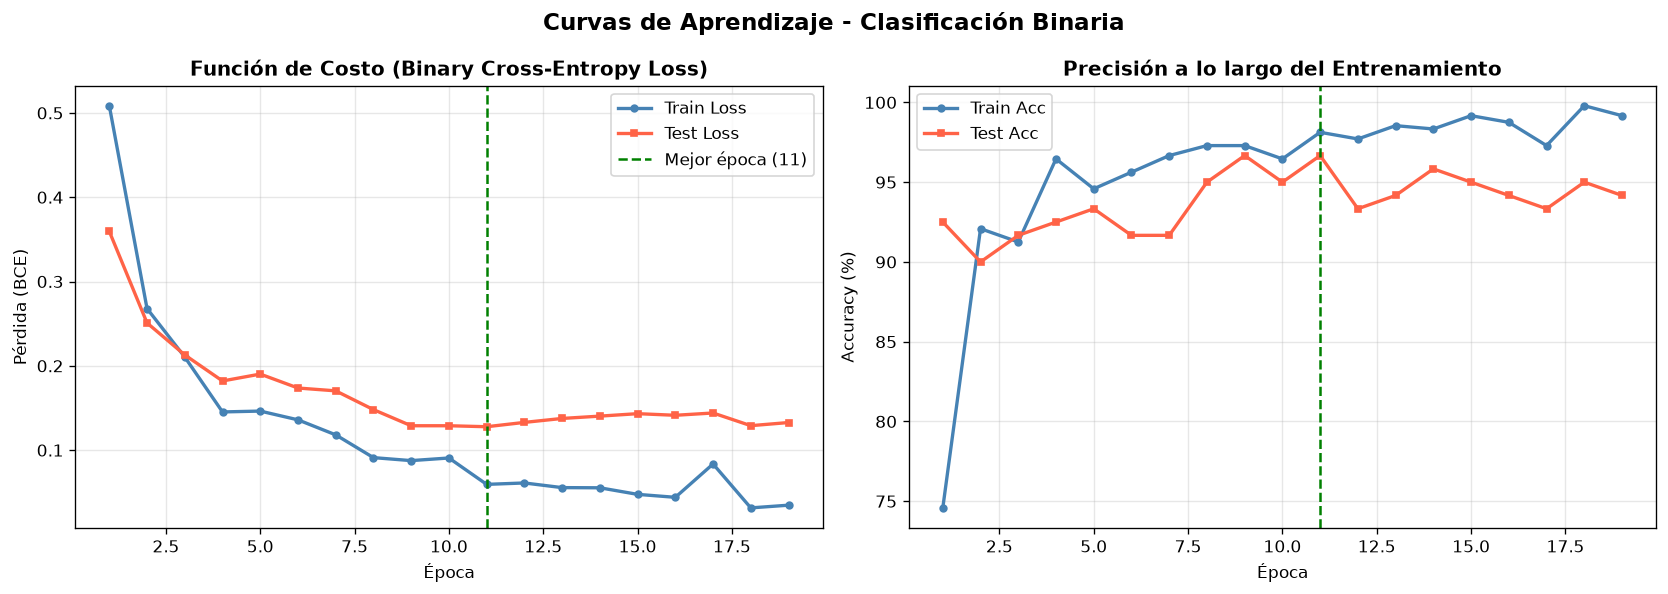

In [8]:
epocas = list(range(1, len(train_losses) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

ax1.plot(epocas, train_losses, label='Train Loss', color='steelblue', lw=2, marker='o', ms=4)
ax1.plot(epocas, test_losses,  label='Test Loss',  color='tomato',    lw=2, marker='s', ms=4)
ax1.axvline(x=mejor_epoca, color='green', linestyle='--', label=f'Mejor época ({mejor_epoca})')
ax1.set_title('Función de Costo (Binary Cross-Entropy Loss)', fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida (BCE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epocas, [a * 100 for a in train_accs], label='Train Acc', color='steelblue', lw=2, marker='o', ms=4)
ax2.plot(epocas, [a * 100 for a in test_accs],  label='Test Acc',  color='tomato',    lw=2, marker='s', ms=4)
ax2.axvline(x=mejor_epoca, color='green', linestyle='--')
ax2.set_title('Precisión a lo largo del Entrenamiento', fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje - Clasificación Binaria', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
model.eval()
todas_preds, todas_real, todas_probs = [], [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        salida = model(X_b.to(device)).squeeze(1)
        probs  = torch.sigmoid(salida)            # Probabilidad de clase male (1)
        preds  = (probs >= 0.5).int()
        
        todas_preds += preds.cpu().tolist()
        todas_real  += y_b.int().tolist()
        todas_probs += probs.cpu().tolist()

todas_preds = np.array(todas_preds)
todas_real  = np.array(todas_real)
todas_probs = np.array(todas_probs)

acc  = accuracy_score(todas_real, todas_preds)
prec = precision_score(todas_real, todas_preds, zero_division=0)
rec  = recall_score(todas_real, todas_preds, zero_division=0)
f1   = f1_score(todas_real, todas_preds, zero_division=0)

print('=' * 50)
print('  REPORTE GLOBAL DE RENDIMIENTO BINARIO (Test Set)')
print('=' * 50)
print(f'  Accuracy  (Exactitud)    : {acc * 100:.2f}%')
print(f'  Precision (Precisión)    : {prec * 100:.2f}%')
print(f'  Recall    (Exhaustividad): {rec * 100:.2f}%')
print(f'  F1-Score                 : {f1 * 100:.2f}%')
print('=' * 50)

print('\nExactitud desglosada por clase:')
cm = confusion_matrix(todas_real, todas_preds)
for i, cls in enumerate(clases):
    correcto = cm[i, i]
    total    = cm[i].sum()
    pct      = (100.0 * correcto / total) if total > 0 else 0.0
    print(f'  Clase {i} ({cls:>6s}): {correcto:3d}/{total:3d} ({pct:5.1f}%)')

  REPORTE GLOBAL DE RENDIMIENTO BINARIO (Test Set)
  Accuracy  (Exactitud)    : 96.67%
  Precision (Precisión)    : 98.28%
  Recall    (Exhaustividad): 95.00%
  F1-Score                 : 96.61%

Exactitud desglosada por clase:
  Clase 0 (female):  59/ 60 ( 98.3%)
  Clase 1 (  male):  57/ 60 ( 95.0%)


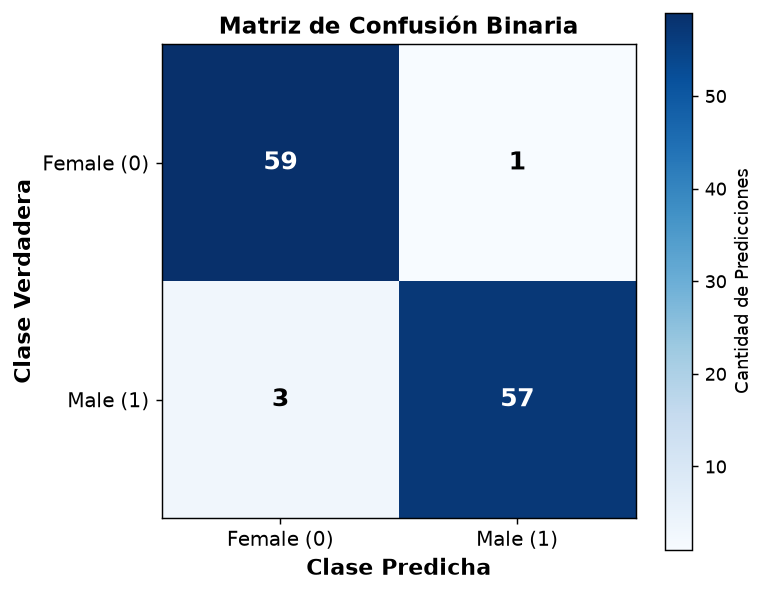

In [10]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=130)

im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Cantidad de Predicciones')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Female (0)', 'Male (1)'], fontsize=11)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Female (0)', 'Male (1)'], fontsize=11)
ax.set_xlabel('Clase Predicha', fontsize=12, fontweight='bold')
ax.set_ylabel('Clase Verdadera', fontsize=12, fontweight='bold')
ax.set_title('Matriz de Confusión Binaria', fontsize=13, fontweight='bold')

umbral = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > umbral else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

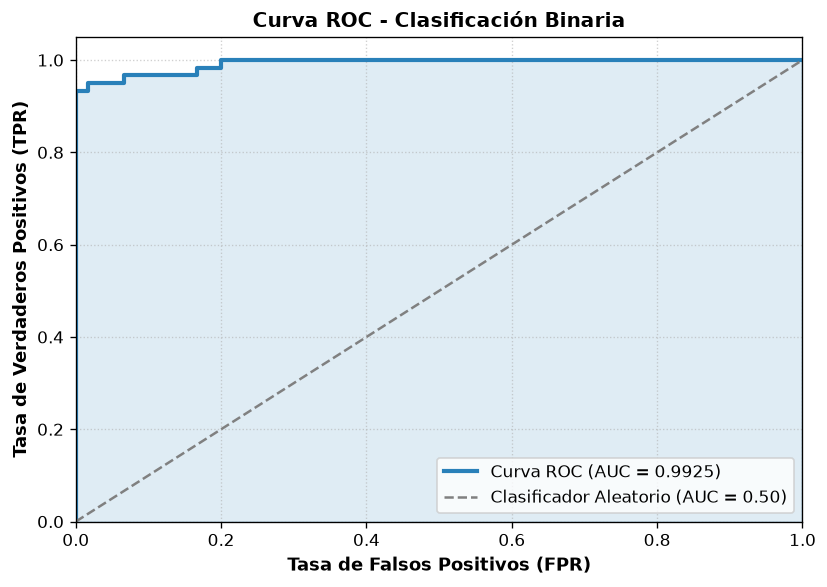

Área bajo la Curva ROC (AUC-ROC): 99.25%


In [11]:
# Curva ROC y Área bajo la Curva (AUC) a partir de las probabilidades sigmoides
fpr, tpr, umbrales = roc_curve(todas_real, todas_probs)
auc_score = roc_auc_score(todas_real, todas_probs)

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

# Graficar la Curva ROC del modelo binario
ax.plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'Curva ROC (AUC = {auc_score:.4f})')

# Línea diagonal de referencia (clasificador aleatorio / azar)
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')

# Área sombreada bajo la curva
ax.fill_between(fpr, tpr, alpha=0.15, color='#2980b9')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11, fontweight='bold')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11, fontweight='bold')
ax.set_title('Curva ROC - Clasificación Binaria', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f'Área bajo la Curva ROC (AUC-ROC): {auc_score * 100:.2f}%')

In [12]:
# Demostración de inferencia binaria con muestras del conjunto de prueba
indices = list(range(min(20, len(test_data))))
muestras_x = torch.stack([test_data[i][0] for i in indices]).to(device)
etiquetas  = [int(test_data[i][1].item()) for i in indices]

model.eval()
with torch.no_grad():
    salidas = model(muestras_x).squeeze(1)
    probs_male = torch.sigmoid(salidas).cpu().tolist()

print('=' * 70)
print(f'{"#":<3} | {"Real":<10} | {"Predicción":<10} | {"P(Male)":<10} | {"Confianza":<10} | {"Estado"}')
print('=' * 70)

aciertos = 0
for k, (real_idx, p_male) in enumerate(zip(etiquetas, probs_male)):
    pred_idx = 1 if p_male >= 0.5 else 0
    real_cls = clases[real_idx]
    pred_cls = clases[pred_idx]
    
    # Confianza respecto a la clase predicha
    confianza = p_male if pred_idx == 1 else (1.0 - p_male)
    
    es_correcto = (real_idx == pred_idx)
    if es_correcto:
        aciertos += 1
        estado = 'Correcto [OK]'
    else:
        estado = 'Error [X]'
        
    print(f'{k+1:<3} | {real_cls:<10} | {pred_cls:<10} | {p_male*100:6.2f}%    | {confianza*100:6.2f}%    | {estado}')

print('=' * 70)
print(f'Aciertos en la demostración: {aciertos}/{len(indices)} ({100*aciertos/len(indices):.1f}%)')

#   | Real       | Predicción | P(Male)    | Confianza  | Estado
1   | female     | male       |  66.32%    |  66.32%    | Error [X]
2   | female     | female     |   0.00%    | 100.00%    | Correcto [OK]
3   | male       | male       |  98.09%    |  98.09%    | Correcto [OK]
4   | male       | male       |  81.42%    |  81.42%    | Correcto [OK]
5   | male       | male       |  98.91%    |  98.91%    | Correcto [OK]
6   | female     | female     |   0.68%    |  99.32%    | Correcto [OK]
7   | male       | male       |  99.74%    |  99.74%    | Correcto [OK]
8   | male       | male       | 100.00%    | 100.00%    | Correcto [OK]
9   | female     | female     |   6.17%    |  93.83%    | Correcto [OK]
10  | male       | male       |  59.72%    |  59.72%    | Correcto [OK]
11  | male       | male       |  99.92%    |  99.92%    | Correcto [OK]
12  | female     | female     |   0.00%    | 100.00%    | Correcto [OK]
13  | male       | male       |  97.56%    |  97.56%    | Correcto [OK]
14 